# SCADE Wrapper & Jupyter Notebook showcase

### Setting up
First, let's import the Python Proxy module generated with Scade One:

In [1]:
import sys, os

harness_dir = os.path.join(os.path.abspath(''), 'LowPassRC_Python')
print(harness_dir)
sys.path.append(harness_dir)
from LowPassRC_Python import LowPassRC_LowPassRC

C:\AnsysDev\Git\pyscadeone-playground\Examples\PyWrapperLowPass\LowPassRC_Python


Then, we can import some libs that will be usefull later on:

In [3]:
#%matplotlib ipympl
import matplotlib.pyplot as plt
import numpy as np
import scipy
import math


Now that everything is ready, we can instantiate our SCADE Operator:

In [4]:
lowpassfilter = LowPassRC_LowPassRC()

Since we will feed discrete signals to our filter, let's write:
- A wrapping function that takes the signal and parameters as input and return the filtered signal.
- A function to compute alpha from the sampling period and the cutoff frequency.

In [5]:
def run_lowpass(alpha:float,x:list):
    lowpassfilter.reset()
    lowpassfilter.inputs.alpha = alpha
    out_list = []
    for i in range(0, len(x)):
        lowpassfilter.inputs.x = x[i]
        lowpassfilter.cycle()
        out_list.append(lowpassfilter.outputs.y)
    return out_list

def get_alpha(wc:float,dt:float):
    RC = 1/(wc*2*math.pi)
    return dt/(RC+dt)

### Time-domain testing
Now, let's see the behavior with a simple step signal:

In [6]:
fs = 100 # Sampling time of 10ms
dt = 1/fs # Sampling time of 10ms
wc = 10 # cutoff frequency of 10 Hz
t = 1 # Signal duration
impulse = np.concatenate((np.zeros(50),np.ones(50))) # Let's make 100 samples, the step is at the 51st sampling.

time = np.linspace(0,t,t*fs)

a = get_alpha(wc,dt) # Compute the alpha value for our filter
filtered_impulse = run_lowpass(a,impulse) # Run the signal through the filter, get the output

... and plot the results:

In [7]:
a

0.38586954509503757

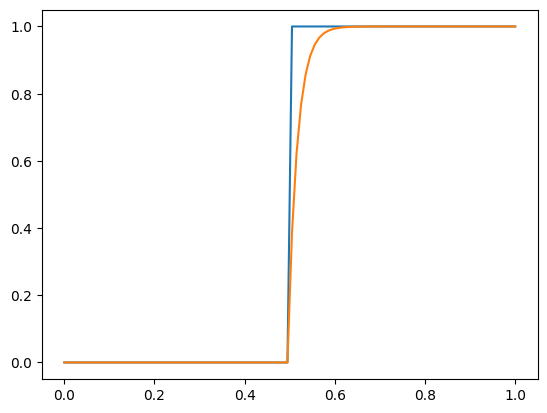

In [8]:
plt.style.use('default')
fig1 = plt.figure()
ax1 = fig1.add_subplot(1, 1, 1)
ax1.plot(time, impulse, label='Step')
ax1.plot(time, filtered_impulse, label='Filtered Step')

Let's try a sinusoid signal:

In [9]:
fs = 500 # Sampling time of 10ms
dt = 1/fs # Sampling time of 10ms
wc = 10 # cutoff frequency of 10 Hz
t = 1 # Signal duration
sin_freq = 8
time = np.linspace(0,t,t*fs)
sin = np.sin(time*2*math.pi*sin_freq)
a = get_alpha(wc,dt)
filtered_sin = run_lowpass(a,sin)

... and plot the results:

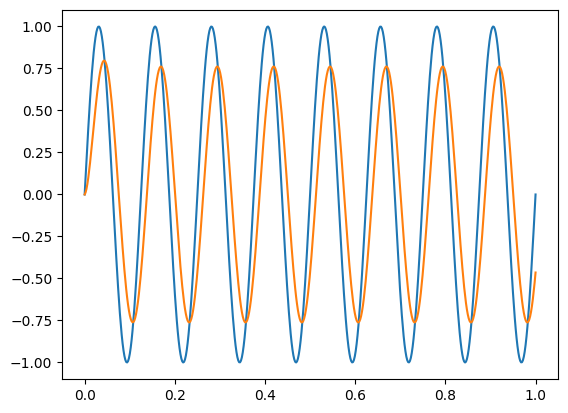

In [10]:
fig2 = plt.figure()
ax2 = fig2.add_subplot(1, 1, 1)
ax2.plot(time, sin, label='Sin')
ax2.plot(time, filtered_sin, label='Filtered Sin')

### Frequency response testing
Let's feed a swept signal to our filter to find out the frequency response:

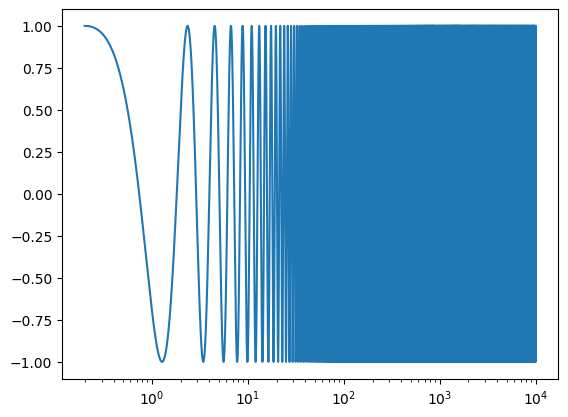

In [11]:
duration = 5 # 5 second signal
sampling_freq = 200000 # 20kHz sampling freq
min_freq = 0.2 # Generate a signal that start at 0.2hz
max_freq = 10000 # And ends up at 10kHz

t1 = np.linspace(0,duration,sampling_freq * duration)
sweep_frequency = [(min_freq*(max_freq/min_freq)**(t/duration)) for t in t1]
sweep_signal = scipy.signal.chirp(t=t1,f0=min_freq,t1=duration,f1=max_freq,method='log') # Generate a swept sine signal

# Plot it
fig3 = plt.figure()
ax3 = fig3.add_subplot(1, 1, 1)
ax3.plot(sweep_frequency, sweep_signal, label='Swept Signal')
ax3.set_xscale('log')


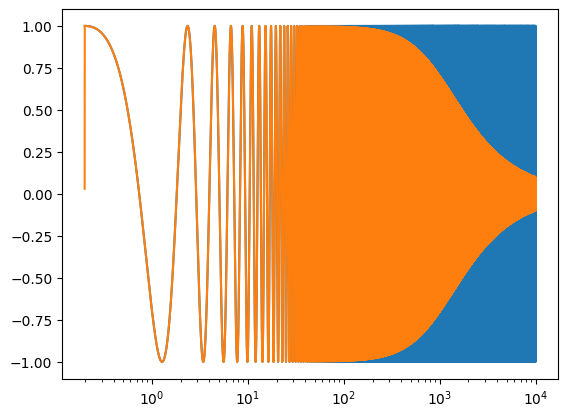

In [12]:
wc =  max_freq*0.1 # 1000 Hz cutoff frequency
dt = 1/sampling_freq
alpha = get_alpha(wc,dt)

output_signal = run_lowpass(alpha=alpha,x=sweep_signal)

# Plot the result
fig4 = plt.figure()
ax4 = fig4.add_subplot(1, 1, 1)
ax4.plot(sweep_frequency, sweep_signal, label='Sweep Signal')
ax4.plot(sweep_frequency, output_signal, label='Output Signal')
ax4.set_xscale('log')

Now, let's create a Bode plot to see the frequency response:

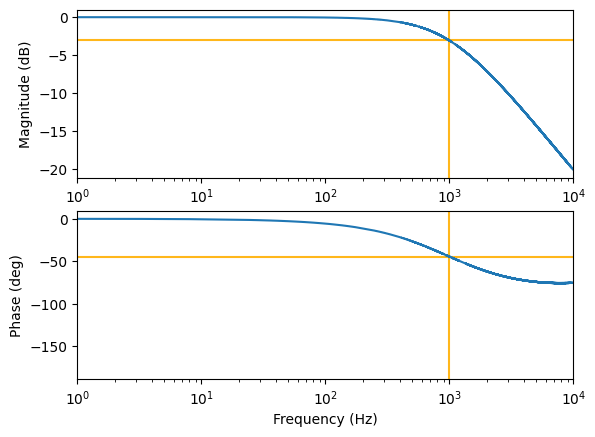

In [13]:
f = np.fft.rfftfreq(sampling_freq*duration, 1 / sampling_freq)
X_in = np.fft.rfft(sweep_signal)
X_out = np.fft.rfft(output_signal)

# Compute frequency response and phase Shift
H = X_out / X_in
magnitude_response = 20 * np.log10(np.abs(H)) # Convert to dB
phase_response = np.unwrap(np.angle(H, deg=True))

# Plot frequency response and phase shift
fig = plt.figure()
ax1 = fig.add_subplot(2,1,1)
ax2 = fig.add_subplot(2,1, 2,sharex=ax1)
ax1.set_xscale('log')
ax1.axvline(wc,color='#ffb71b')
ax1.axline((0.0,-3.0),(wc,-3.0),color='#ffb71b') # We expect attenuation at wc to be -3dB
ax1.set_ylabel('Magnitude (dB)')
ax2.set_xlabel('Frequency (Hz)')
ax2.axvline(wc,color='#ffb71b')
ax2.axline((0.0,-45.0),(wc,-45.0),color='#ffb71b') # And phase shift at wc to be at -45 deg
ax1.set_xlim(1,max_freq)
ax2.set_ylabel('Phase (deg)')
ax1.plot(f, magnitude_response)
ax2.plot(f, phase_response)